---
date: "2026-07-18"
date-modified: last-modified
format:
  html:
    toc: true
---

# Covariance and Correlation

While the [Expected Value](expectation.ipynb) $E(X)$ locates the center of mass of a distribution and [Variance](variance.ipynb) $\text{Var}(X)$ quantifies the dispersion of a single [random variable](random-variables.ipynb) around that center, many probabilistic systems involve multiple variables interacting simultaneously. To characterize the linear relationship and joint dispersion between two random variables in a [joint distribution](joint-distribution.ipynb), we introduce **covariance** and **correlation**.

## 1\. Definition and Fundamental Properties of Covariance

**Definition (Covariance):**
Given two random variables $X$ and $Y$ with means $\mu_X = E(X)$ and $\mu_Y = E(Y)$, the **covariance** between $X$ and $Y$, denoted $\text{Cov}(X, Y)$, is defined as the expected value of the product of their deviations from their respective means:

$$
\text{Cov}(X, Y) = E[(X - E(X))(Y - E(Y))]
$$

Computing covariance directly from this definition often requires expanding difficult algebraic products inside sums or integrals. Using the [linearity of expectation](expectation.ipynb#properties-of-expectation), we can derive a much simpler computational shortcut.

**Theorem (Alternate Computational Formula):**
For any two random variables $X$ and $Y$,

$$
\text{Cov}(X, Y) = E(XY) - E(X)E(Y)
$$

::: {.callout-tip collapse="true"}
## Proof of Alternate Computational Formula
Let $\mu_X = E(X)$ and $\mu_Y = E(Y)$. Since $\mu_X$ and $\mu_Y$ are fixed scalar constants (not random variables), we expand the product inside the expectation:

$$
\begin{aligned}
\text{Cov}(X, Y) &= E[(X - \mu_X)(Y - \mu_Y)] \\
&= E[XY - \mu_Y X - \mu_X Y + \mu_X \mu_Y]
\end{aligned}
$$

Applying the linearity of expectation ($E[aU + bV] = aE[U] + bE[V]$), we distribute the expectation operator across the terms and factor out the constants:

$$
\begin{aligned}
\text{Cov}(X, Y) &= E(XY) - \mu_Y E(X) - \mu_X E(Y) + E(\mu_X \mu_Y) \\
&= E(XY) - \mu_Y \mu_X - \mu_X \mu_Y + \mu_X \mu_Y \\
&= E(XY) - \mu_X \mu_Y \\
&= E(XY) - E(X)E(Y)
\end{aligned}
$$

$\blacksquare$
:::

::: {.callout-note}
## Intuition: Geometric Interpretation of Covariance
Consider the coordinate plane centered at $(\mu_X, \mu_Y)$. The product $(X - \mu_X)(Y - \mu_Y)$ represents the signed area of the rectangle formed by a sample point $(X, Y)$ and the center of mass. If $X$ and $Y$ tend to move in the same direction—both being above their means or both below—the point falls in the first or third quadrant, yielding a positive product. Conversely, if one variable is above its mean while the other is below, the point falls in the second or fourth quadrant, yielding a negative product. Covariance is simply the probability-weighted average of these signed rectangular areas across the entire sample space.
:::


## 2\. Algebraic Properties and Bilinearity

Covariance obeys a set of fundamental algebraic identities that make manipulating linear combinations of random variables systematic and powerful.

**Proposition (Properties of Covariance):**
For any random variables $X, Y, Z, W$ and real constants $a, b, c, d$:

1. **Self-Covariance is Variance:**
   $$
   \text{Cov}(X, X) = \text{Var}(X)
   $$
2. **Symmetry:**
   $$
   \text{Cov}(X, Y) = \text{Cov}(Y, X)
   $$
3. **Covariance with a Constant:**
   $$
   \text{Cov}(X, c) = 0
   $$
4. **Scaling (Homogeneity):**
   $$
   \text{Cov}(cX, Y) = c\text{Cov}(X, Y)
   $$
5. **Additivity in One Argument:**
   $$
   \text{Cov}(X, Y + Z) = \text{Cov}(X, Y) + \text{Cov}(X, Z)
   $$
6. **Bilinearity for Two Sums:**
   $$
   \begin{aligned}
   \text{Cov}(X + Y, Z + W) &= \text{Cov}(X, Z) + \text{Cov}(X, W) + \text{Cov}(Y, Z) + \text{Cov}(Y, W)
   \end{aligned}
   $$

**General Bilinearity Theorem:**
More generally, the covariance between any two linear combinations of random variables is bilinear:

$$
\text{Cov}\left(\sum_{i=1}^m a_i X_i, \sum_{j=1}^n b_j Y_j\right) = \sum_{i=1}^m \sum_{j=1}^n a_i b_j \text{Cov}(X_i, Y_j)
$$

::: {.callout-tip collapse="true"}
## Proof of General Bilinearity
Using the definition $\text{Cov}(U, V) = E[(U - E(U))(V - E(V))]$, let $U = \sum_{i=1}^m a_i X_i$ and $V = \sum_{j=1}^n b_j Y_j$. By linearity of expectation, $E(U) = \sum_{i=1}^m a_i E(X_i)$ and $E(V) = \sum_{j=1}^n b_j E(Y_j)$. Subtracting the means gives:

$$
\begin{aligned}
U - E(U) &= \sum_{i=1}^m a_i(X_i - E(X_i)) \\
V - E(V) &= \sum_{j=1}^n b_j(Y_j - E(Y_j))
\end{aligned}
$$

Taking the expectation of their product:

$$
\begin{aligned}
\text{Cov}(U, V) &= E\left[ \left(\sum_{i=1}^m a_i(X_i - E(X_i))\right) \left(\sum_{j=1}^n b_j(Y_j - E(Y_j))\right) \right] \\
&= E\left[ \sum_{i=1}^m \sum_{j=1}^n a_i b_j (X_i - E(X_i))(Y_j - E(Y_j)) \right] \\
&= \sum_{i=1}^m \sum_{j=1}^n a_i b_j E[(X_i - E(X_i))(Y_j - E(Y_j))] \\
&= \sum_{i=1}^m \sum_{j=1}^n a_i b_j \text{Cov}(X_i, Y_j)
\end{aligned}
$$

$\blacksquare$
:::

**Theorem (Variance of a Linear Combination / Sum):**
As a direct consequence of bilinearity and the self-covariance identity, the variance of the sum of two random variables is:

$$
\text{Var}(X_1 + X_2) = \text{Var}(X_1) + \text{Var}(X_2) + 2\text{Cov}(X_1, X_2)
$$

In general, for $n$ random variables $X_1, X_2, \dots, X_n$:

$$
\begin{aligned}
\text{Var}\left(\sum_{i=1}^n X_i\right) &= \sum_{i=1}^n \text{Var}(X_i) + 2\sum_{1 \le i < j \le n} \text{Cov}(X_i, X_j) \\
&= \sum_{i=1}^n \sum_{j=1}^n \text{Cov}(X_i, X_j)
\end{aligned}
$$

::: {.callout-tip collapse="true"}
## Proof of Variance of a Sum
We apply the general bilinearity theorem with $U = V = \sum_{i=1}^n X_i$:

$$
\begin{aligned}
\text{Var}\left(\sum_{i=1}^n X_i\right) &= \text{Cov}\left(\sum_{i=1}^n X_i, \sum_{j=1}^n X_j\right) \\
&= \sum_{i=1}^n \sum_{j=1}^n \text{Cov}(X_i, X_j)
\end{aligned}
$$

Splitting the double sum into diagonal terms ($i = j$) and off-diagonal terms ($i \neq j$):

$$
\begin{aligned}
\sum_{i=1}^n \sum_{j=1}^n \text{Cov}(X_i, X_j) &= \sum_{i=1}^n \text{Cov}(X_i, X_i) + \sum_{i \neq j} \text{Cov}(X_i, X_j) \\
&= \sum_{i=1}^n \text{Var}(X_i) + 2\sum_{1 \le i < j \le n} \text{Cov}(X_i, X_j)
\end{aligned}
$$

where the factor of $2$ arises from symmetry ($\text{Cov}(X_i, X_j) = \text{Cov}(X_j, X_i)$ for every pair $i < j$). $\blacksquare$
:::


## 3\. Independence versus Uncorrelatedness

A crucial conceptual distinction in probability theory is the relationship between statistical [independence](independence-of-rvs.ipynb) and zero covariance (**uncorrelatedness**).

**Theorem:**
If two random variables $X$ and $Y$ are independent, then they are uncorrelated; that is, $\text{Cov}(X, Y) = 0$.

::: {.callout-tip collapse="true"}
## Proof that Independence Implies Uncorrelatedness
If $X$ and $Y$ are independent, the expectation of their product factors completely into the product of their individual expectations: $E(XY) = E(X)E(Y)$. Substituting this identity into our alternate covariance formula gives:

$$
\text{Cov}(X, Y) = E(XY) - E(X)E(Y) = E(X)E(Y) - E(X)E(Y) = 0
$$

$\blacksquare$
:::

::: {.callout-warning}
## The Converse is False!
Zero covariance does **not** imply independence ($\text{Cov}(X, Y) = 0 \centernot\implies X \perp\!\!\!\perp Y$). Covariance strictly detects and quantifies *linear* association. Two random variables can have exactly zero covariance while being strongly—or even deterministically—dependent through a non-linear relationship.
:::

**Counterexample (Uncorrelated but Deterministically Dependent):**
Let $Z \sim \mathcal{N}(0, 1)$ follow a [Standard Normal distribution](normal-distribution.ipynb), and define two random variables $X = Z$ and $Y = Z^2$.
Observe that $Y$ is a deterministic function of $X$ ($Y = X^2$), meaning $X$ and $Y$ are completely dependent, yet $\text{Cov}(X, Y) = 0$.

::: {.callout-tip collapse="true"}
## Proof / Verification of Counterexample
We compute the covariance between $X = Z$ and $Y = Z^2$ using the alternate computational formula:

$$
\begin{aligned}
\text{Cov}(X, Y) &= E(XY) - E(X)E(Y) \\
&= E(Z \cdot Z^2) - E(Z)E(Z^2) \\
&= E(Z^3) - E(Z)E(Z^2)
\end{aligned}
$$

Because the probability density function of $Z \sim \mathcal{N}(0, 1)$ is perfectly symmetric around $0$, every odd central moment of $Z$ evaluates to zero ($E(Z) = 0$ and $E(Z^3) = 0$). Therefore:

$$
\text{Cov}(X, Y) = 0 - 0 \cdot E(Z^2) = 0
$$

Thus, $X$ and $Y$ are completely uncorrelated ($\text{Cov}(X, Y) = 0$) despite exhibiting absolute functional dependence. $\blacksquare$
:::


## 4\. Correlation and Cauchy-Schwarz Bounds

A practical limitation of covariance is that its magnitude scales directly with the units of measurement of both $X$ and $Y$. For instance, measuring distance in millimeters instead of meters increases the covariance by a factor of $1,000,000$. To obtain a standardized, unitless measure of linear association, we normalize the covariance by the standard deviations of the variables.

**Definition (Correlation Coefficient):**
Given two random variables $X$ and $Y$ with non-zero standard deviations $\text{SD}(X) = \sqrt{\text{Var}(X)}$ and $\text{SD}(Y) = \sqrt{\text{Var}(Y)}$, the **correlation coefficient** (or Pearson's correlation), denoted $\text{Corr}(X, Y)$ or $\rho_{X,Y}$, is defined as:

$$
\begin{aligned}
\text{Corr}(X, Y) &= \frac{\text{Cov}(X, Y)}{\text{SD}(X)\text{SD}(Y)} \\
&= \text{Cov}\left(\frac{X - E(X)}{\text{SD}(X)}, \frac{Y - E(Y)}{\text{SD}(Y)}\right)
\end{aligned}
$$

**Theorem (Bounds on Correlation):**
For any random variables $X$ and $Y$ with non-zero variances,

$$
-1 \le \text{Corr}(X, Y) \le 1
$$

Furthermore, $|\text{Corr}(X, Y)| = 1$ if and only if there exist real constants $a \neq 0$ and $b$ such that $Y = aX + b$ almost surely (with $a > 0$ yielding $\rho = 1$ and $a < 0$ yielding $\rho = -1$).

We provide two rigorous proofs of this fundamental inequality: one based on standardizing variables and one applying the Cauchy-Schwarz inequality directly.

::: {.callout-tip collapse="true"}
## Proof 1: Via Standardization and Non-Negativity of Variance
Without loss of generality (WLOG), assume that $X$ and $Y$ have been standardized so that $E(X) = E(Y) = 0$ and $\text{Var}(X) = \text{Var}(Y) = 1$. In this standardized setting, $\text{SD}(X) = \text{SD}(Y) = 1$, so the correlation equals the covariance: $\rho = \text{Corr}(X, Y) = \text{Cov}(X, Y)$.
First, consider the variance of the sum $X + Y$:

$$
\begin{aligned}
\text{Var}(X + Y) &= \text{Var}(X) + \text{Var}(Y) + 2\text{Cov}(X, Y) \\
&= 1 + 1 + 2\rho \\
&= 2 + 2\rho
\end{aligned}
$$

Because the variance of any real random variable is non-negative ($\text{Var}(U) \ge 0$):

$$
2 + 2\rho \ge 0 \implies 2\rho \ge -2 \implies \rho \ge -1
$$

Second, consider the variance of the difference $X - Y$:

$$
\begin{aligned}
\text{Var}(X - Y) &= \text{Var}(X) + \text{Var}(Y) - 2\text{Cov}(X, Y) \\
&= 1 + 1 - 2\rho \\
&= 2 - 2\rho
\end{aligned}
$$

Applying the non-negativity of variance once again:

$$
2 - 2\rho \ge 0 \implies 2\rho \le 2 \implies \rho \le 1
$$

Combining the two inequalities directly yields $-1 \le \rho \le 1$. $\blacksquare$
:::

::: {.callout-tip collapse="true"}
## Proof 2: Via Direct Application of Cauchy-Schwarz
We can also prove this bound using the [Cauchy-Schwarz Inequality](Cauchy-Schwarz-inequality.ipynb) for random variables, which asserts that for any square-integrable random variables $U$ and $V$, $|E(UV)| \le \sqrt{E(U^2)E(V^2)}$.
Define the centered deviations $U = X - E(X)$ and $V = Y - E(Y)$.
Observe that:

$$
\begin{aligned}
E(UV) &= E[(X - E(X))(Y - E(Y))] = \text{Cov}(X, Y) \\
E(U^2) &= E[(X - E(X))^2] = \text{Var}(X) \\
E(V^2) &= E[(Y - E(Y))^2] = \text{Var}(Y)
\end{aligned}
$$

By the Cauchy-Schwarz inequality:

$$
|\text{Cov}(X, Y)| \le \sqrt{\text{Var}(X)\text{Var}(Y)} = \text{SD}(X)\text{SD}(Y)
$$

Dividing both sides by the positive denominator $\text{SD}(X)\text{SD}(Y)$ gives:

$$
\frac{|\text{Cov}(X, Y)|}{\text{SD}(X)\text{SD}(Y)} \le 1 \implies |\text{Corr}(X, Y)| \le 1 \implies -1 \le \text{Corr}(X, Y) \le 1
$$

$\blacksquare$
:::

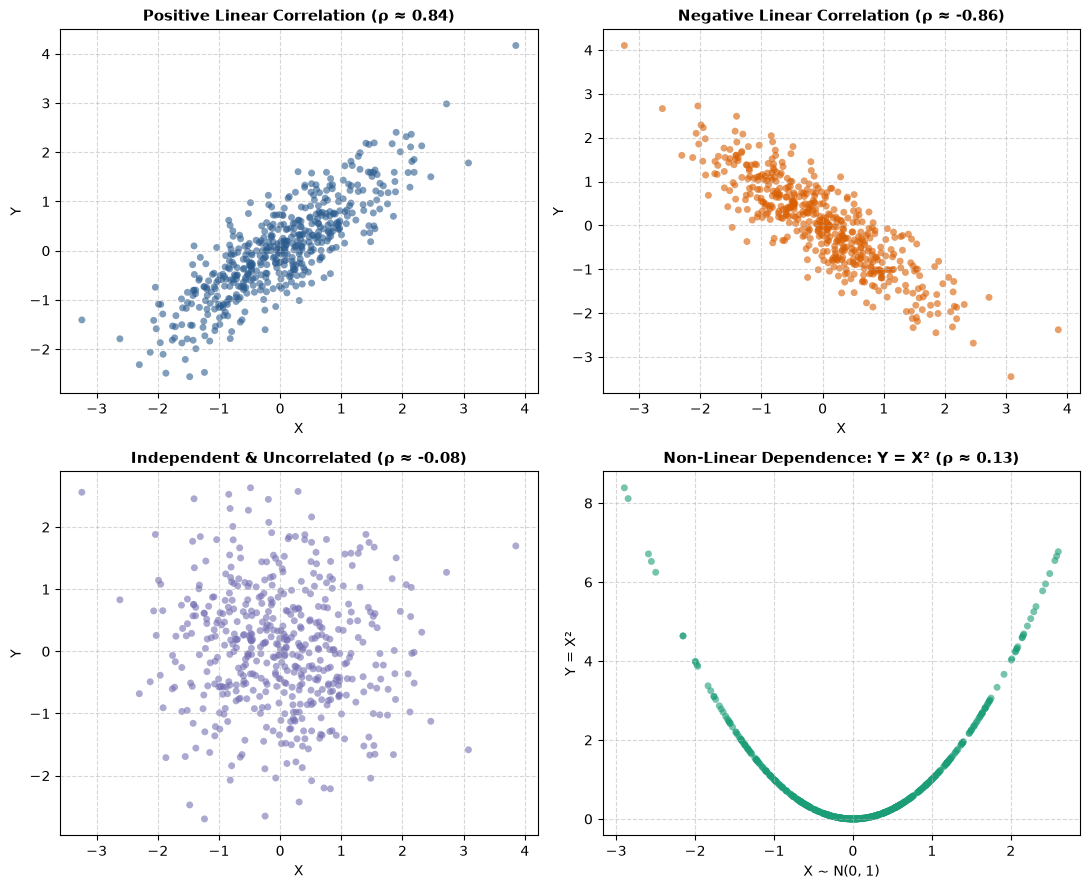

In [1]:
#| label: fig-correlation-examples
#| fig-cap: "Scatter plots demonstrating varying correlation coefficients. Notice how strong linear relationships approach |ρ| = 1, while the bottom-right panel confirms that a deterministic parabolic relationship yields exactly ρ = 0 due to symmetry."

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 500

# 1. Positive Correlation
z1 = np.random.normal(0, 1, n_samples)
z2 = np.random.normal(0, 1, n_samples)
x_pos = z1
y_pos = 0.85 * z1 + np.sqrt(1 - 0.85**2) * z2
corr_pos = np.corrcoef(x_pos, y_pos)[0, 1]

# 2. Negative Correlation
x_neg = z1
y_neg = -0.85 * z1 + np.sqrt(1 - 0.85**2) * z2
corr_neg = np.corrcoef(x_neg, y_neg)[0, 1]

# 3. Independent / Uncorrelated
x_ind = z1
y_ind = z2
corr_ind = np.corrcoef(x_ind, y_ind)[0, 1]

# 4. Non-Linear Dependence Counterexample (Y = X^2)
x_nl = np.random.normal(0, 1, n_samples)
y_nl = x_nl**2
corr_nl = np.corrcoef(x_nl, y_nl)[0, 1]

fig, axs = plt.subplots(2, 2, figsize=(11, 9))

# Plot 1: Positive
axs[0, 0].scatter(x_pos, y_pos, alpha=0.6, color='#2b5c8f', edgecolors='none', s=25)
axs[0, 0].set_title(f'Positive Linear Correlation (ρ ≈ {corr_pos:.2f})', fontsize=11, fontweight='bold')
axs[0, 0].set_xlabel('X')
axs[0, 0].set_ylabel('Y')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Negative
axs[0, 1].scatter(x_neg, y_neg, alpha=0.6, color='#d95f02', edgecolors='none', s=25)
axs[0, 1].set_title(f'Negative Linear Correlation (ρ ≈ {corr_neg:.2f})', fontsize=11, fontweight='bold')
axs[0, 1].set_xlabel('X')
axs[0, 1].set_ylabel('Y')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Independent
axs[1, 0].scatter(x_ind, y_ind, alpha=0.6, color='#7570b3', edgecolors='none', s=25)
axs[1, 0].set_title(f'Independent & Uncorrelated (ρ ≈ {corr_ind:.2f})', fontsize=11, fontweight='bold')
axs[1, 0].set_xlabel('X')
axs[1, 0].set_ylabel('Y')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

# Plot 4: Parabolic Dependence
axs[1, 1].scatter(x_nl, y_nl, alpha=0.6, color='#1b9e77', edgecolors='none', s=25)
axs[1, 1].set_title(f'Non-Linear Dependence: Y = X² (ρ ≈ {corr_nl:.2f})', fontsize=11, fontweight='bold')
axs[1, 1].set_xlabel('X ~ N(0, 1)')
axs[1, 1].set_ylabel('Y = X²')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 5\. Applications: Covariances and Variances of Distributions

We now apply bilinearity, indicator variable decompositions, and the variance of a sum formula to derive exact covariances and variances for classic discrete probability distributions.

### 5.1\. Covariance in the Multinomial Distribution

**Example (Multinomial Covariance):**
Let $(X_1, X_2, \dots, X_k) \sim \text{Mult}_k(n, \vec{p})$ follow a [Multinomial distribution](multinomial-distribution.ipynb) with $n$ independent trials and category probabilities $\vec{p} = (p_1, p_2, \dots, p_k)$ such that $\sum_{i=1}^k p_i = 1$. Each variable $X_i$ counts the number of times category $i$ occurs across all $n$ trials.
For any pair of indices $i, j \in \{1, 2, \dots, k\}$, the covariances are:

1. **Self-Covariance ($i = j$):**
   $$
   \text{Cov}(X_i, X_i) = \text{Var}(X_i) = n p_i (1 - p_i)
   $$
2. **Cross-Covariance ($i \neq j$):**
   $$
   \text{Cov}(X_i, X_j) = -n p_i p_j
   $$

::: {.callout-tip collapse="true"}
## Proof / Derivation of Multinomial Covariances
**Case 1 ($i = j$): Self-Covariance (Marginal Variance)**
When $i = j$, self-covariance is simply the variance: $\text{Cov}(X_i, X_i) = \text{Var}(X_i)$.
By partitioning outcomes into two groups—"category $i$" versus "all other categories"—the marginal distribution of $X_i$ reduces exactly to a [Binomial distribution](bernoulli-and-binomial-distributions.ipynb) with parameters $n$ and $p_i$: $X_i \sim \text{Bin}(n, p_i)$.
Therefore:

$$
\text{Cov}(X_i, X_i) = \text{Var}(X_i) = n p_i (1 - p_i)
$$

**Case 2 ($i \neq j$): Cross-Covariance**
Without loss of generality, let us compute $\text{Cov}(X_1, X_2)$.
Consider the sum $X_1 + X_2$, which counts the total occurrences of either category $1$ or category $2$. By **lumping** categories $1$ and $2$ together into a single combined category with probability $p_1 + p_2$, the random variable $X_1 + X_2$ also follows a Binomial distribution:

$$
X_1 + X_2 \sim \text{Bin}(n, p_1 + p_2)
$$

The variance of this combined binomial count is immediately given by:

$$
\text{Var}(X_1 + X_2) = n(p_1 + p_2)(1 - (p_1 + p_2)) = n(p_1 + p_2)(1 - p_1 - p_2)
$$

At the same time, we expand $\text{Var}(X_1 + X_2)$ using our formula for the variance of a sum:

$$
\text{Var}(X_1 + X_2) = \text{Var}(X_1) + \text{Var}(X_2) + 2\text{Cov}(X_1, X_2)
$$

Substituting the marginal variances $\text{Var}(X_1) = n p_1(1 - p_1)$ and $\text{Var}(X_2) = n p_2(1 - p_2)$ into this expansion yields:

$$
n(p_1 + p_2)(1 - p_1 - p_2) = n p_1(1 - p_1) + n p_2(1 - p_2) + 2\text{Cov}(X_1, X_2)
$$

We expand the left-hand side algebraically:

$$
\begin{aligned}
n(p_1 + p_2)(1 - p_1 - p_2) &= n(p_1 - p_1^2 - p_1 p_2 + p_2 - p_1 p_2 - p_2^2) \\
&= n(p_1 + p_2 - p_1^2 - p_2^2 - 2p_1 p_2)
\end{aligned}
$$

And we expand the right-hand side:

$$
\begin{aligned}
n p_1(1 - p_1) + n p_2(1 - p_2) + 2\text{Cov}(X_1, X_2) &= n(p_1 - p_1^2 + p_2 - p_2^2) + 2\text{Cov}(X_1, X_2)
\end{aligned}
$$

Equating the two expansions and subtracting the common terms $n(p_1 + p_2 - p_1^2 - p_2^2)$ from both sides leaves:

$$
-2n p_1 p_2 = 2\text{Cov}(X_1, X_2) \implies \text{Cov}(X_1, X_2) = -n p_1 p_2
$$

By symmetry, for any distinct categories $i \neq j$:

$$
\text{Cov}(X_i, X_j) = -n p_i p_j
$$

$\blacksquare$
:::

::: {.callout-note}
## Intuition: Negative Covariance in Multinomial Trials
The negative cross-covariance $\text{Cov}(X_i, X_j) = -n p_i p_j$ reflects a fundamental competitive constraint: because the total number of trials across all categories is strictly fixed at $n$ ($\sum_{m=1}^k X_m = n$), every trial that lands in category $i$ is one fewer trial available to land in category $j$. Consequently, when $X_i$ is higher than average, $X_j$ is forced to be lower than average.
:::


### 5.2\. Variance of the Binomial Distribution via Indicator Sums

**Example (Binomial Variance):**
Let $X \sim \text{Bin}(n, p)$ follow a [Binomial distribution](bernoulli-and-binomial-distributions.ipynb). The variance of $X$ is given by:

$$
\text{Var}(X) = np(1 - p) = npq
$$

::: {.callout-tip collapse="true"}
## Proof / Derivation via Indicator Sums
Instead of calculating $E[(X - np)^2]$ directly using binomial sums, we express $X$ as the sum of $n$ independent [indicator random variables](indicator-rv.ipynb):

$$
X = X_1 + X_2 + \dots + X_n, \quad \text{where } X_j \stackrel{\text{i.i.d.}}{\sim} \text{Bern}(p)
$$

Here, $X_j = 1$ if the $j$-th trial is a success and $0$ otherwise.
For any individual Bernoulli indicator $X_j$, $E(X_j) = p$ and $E(X_j^2) = 1^2 \cdot p + 0^2 \cdot (1 - p) = p$. Its variance is:

$$
\text{Var}(X_j) = E(X_j^2) - (E(X_j))^2 = p - p^2 = p(1 - p) = pq
$$

where $q = 1 - p$.
Because the trials are independent, all pairwise covariances vanish: $\text{Cov}(X_i, X_j) = 0$ for all $i \neq j$.
Applying the variance of a sum formula:

$$
\begin{aligned}
\text{Var}(X) &= \sum_{i=1}^n \text{Var}(X_i) + 2\sum_{1 \le i < j \le n} \text{Cov}(X_i, X_j) \\
&= \sum_{i=1}^n pq + 0 \\
&= npq = np(1 - p)
\end{aligned}
$$

$\blacksquare$
:::

### 5.3\. Variance and Covariances of the Hypergeometric Distribution

**Example (Hypergeometric Variance):**
Let $X \sim \text{HGeom}(w, b, n)$ follow a [Hypergeometric distribution](hypergeometric-distribution.ipynb), representing the number of white balls drawn when drawing $n$ balls **without replacement** from an urn containing $w$ white balls and $b$ black balls (total population $N = w + b$, with initial white proportion $p = \frac{w}{N}$).
For any distinct draws $i \neq j$, the pairwise covariance is:

$$
\text{Cov}(X_i, X_j) = -\frac{p(1 - p)}{N - 1}
$$

And the total variance of the number of white balls $X$ is:

$$
\text{Var}(X) = np(1 - p)\left(\frac{N - n}{N - 1}\right)
$$

::: {.callout-tip collapse="true"}
## Proof / Derivation via Indicator Sums
We decompose $X$ into a sum of indicators across the $n$ draws:

$$
X = X_1 + X_2 + \dots + X_n, \quad \text{where } X_j = \begin{cases} 1 & \text{if the } j\text{-th drawn ball is white} \\ 0 & \text{otherwise} \end{cases}
$$

**Step 1: Marginal Variances**
By symmetry—since every ball in the urn has an equal probability of being selected on the $j$-th draw prior to observing other draws—each indicator $X_j$ has identical marginal probability $P(X_j = 1) = \frac{w}{w+b} = p$.
Thus, the variance of each individual draw matches the Bernoulli variance:

$$
\text{Var}(X_j) = p(1 - p) = \frac{w}{w+b} \left(1 - \frac{w}{w+b}\right) = \frac{wb}{(w+b)^2}
$$

**Step 2: Pairwise Covariances**
Because sampling occurs without replacement, the draws are **not independent**.
By symmetry across draw indices, the covariance between any two distinct draws $i \neq j$ equals $\text{Cov}(X_1, X_2)$.
Using the alternate covariance formula:

$$
\text{Cov}(X_1, X_2) = E(X_1 X_2) - E(X_1)E(X_2)
$$

Recall the foundational indicator algebra: for any events $A$ and $B$, $I_A I_B = I_{A \cap B}$ and $I_A^2 = I_A$.
The product $X_1 X_2$ is the indicator for the joint event that both the 1st and 2nd balls drawn are white. Thus:

$$
\begin{aligned}
E(X_1 X_2) &= P(X_1 = 1 \text{ and } X_2 = 1) \\
&= P(X_1 = 1) P(X_2 = 1 \mid X_1 = 1) \\
&= \frac{w}{w+b} \cdot \frac{w-1}{w+b-1}
\end{aligned}
$$

Substituting $E(X_1 X_2)$ along with $E(X_1) = E(X_2) = \frac{w}{w+b}$ into the covariance formula yields:

$$
\text{Cov}(X_1, X_2) = \frac{w}{w+b}\left(\frac{w-1}{w+b-1}\right) - \left(\frac{w}{w+b}\right)^2
$$

We simplify this expression by letting total population $N = w + b$ and initial white ball proportion $p = \frac{w}{N}$ (so $w = Np$ and $1 - p = \frac{b}{N}$):

$$
\begin{aligned}
\text{Cov}(X_1, X_2) &= p\left(\frac{Np - 1}{N - 1}\right) - p^2 \\
&= p\left(\frac{Np - 1 - p(N - 1)}{N - 1}\right) \\
&= p\left(\frac{Np - 1 - Np + p}{N - 1}\right) \\
&= p\left(\frac{p - 1}{N - 1}\right) \\
&= -\frac{p(1 - p)}{N - 1}
\end{aligned}
$$

Because $N > 1$ and $0 < p < 1$, the pairwise covariance $\text{Cov}(X_i, X_j) = -\frac{p(1 - p)}{N - 1}$ is strictly negative.

**Step 3: Total Variance via Bilinearity**
We now assemble the total variance of $X = \sum_{j=1}^n X_j$. The double sum over indices contains $n$ marginal variance terms and $2\binom{n}{2} = n(n-1)$ cross-covariance terms:

$$
\begin{aligned}
\text{Var}(X) &= n\text{Var}(X_1) + 2\binom{n}{2}\text{Cov}(X_1, X_2) \\
&= n\text{Var}(X_1) + n(n - 1)\text{Cov}(X_1, X_2) \\
&= np(1 - p) + n(n - 1)\left(-\frac{p(1 - p)}{N - 1}\right) \\
&= np(1 - p)\left[1 - \frac{n - 1}{N - 1}\right]
\end{aligned}
$$

We simplify the bracketed correction factor:

$$
1 - \frac{n - 1}{N - 1} = \frac{(N - 1) - (n - 1)}{N - 1} = \frac{N - n}{N - 1}
$$

Therefore, the exact variance of the Hypergeometric distribution is:

$$
\text{Var}(X) = np(1 - p)\left(\frac{N - n}{N - 1}\right)
$$

$\blacksquare$
:::

**Extreme Cases and the Finite Population Correction Factor:**
The factor $\frac{N - n}{N - 1}$ is called the **finite population correction factor**. It directly connects the variance of sampling without replacement to sampling with replacement:

1. **Single Sample ($n = 1$):**
   When drawing only $1$ ball, $\frac{N - 1}{N - 1} = 1$, and the variance reduces to $p(1 - p) = pq$, identical to a single Bernoulli trial.
2. **Infinite Population or Sampling with Replacement ($N \to \infty$):**
   For any fixed sample size $n$, as the total population $N \to \infty$, the correction factor satisfies $\lim_{N \to \infty} \frac{N - n}{N - 1} = 1$. In this limit, depletion of the population becomes negligible, sampling without replacement behaves like sampling with replacement, and the variance converges precisely to the Binomial variance $np(1 - p) = npq$.

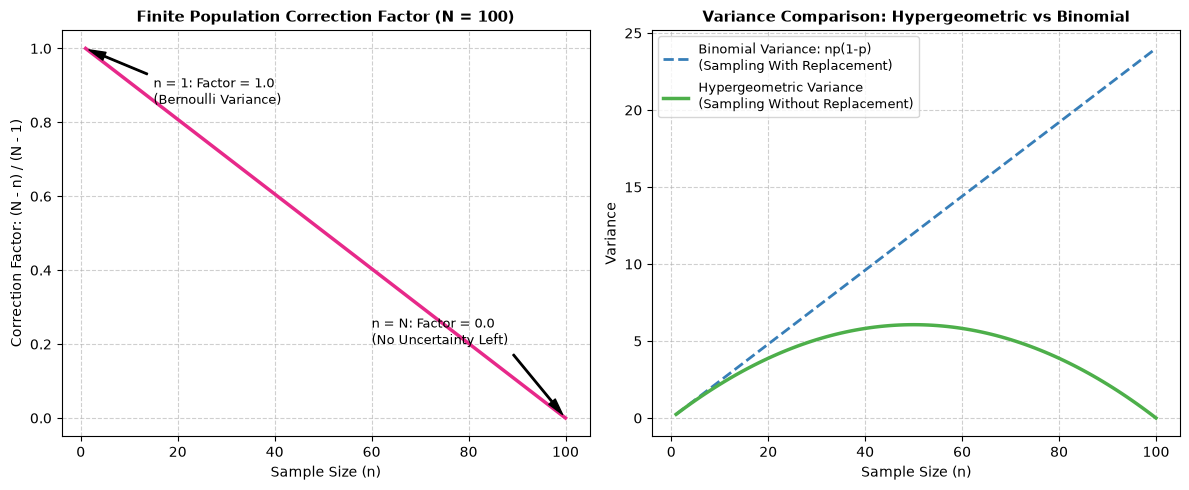

In [2]:
#| label: fig-hypergeometric-correction
#| fig-cap: "Visualization of the Finite Population Correction Factor and its impact on total variance. As the sample size n approaches the population size N, negative pairwise covariance accumulates, driving the total variance of the Hypergeometric distribution down to zero."

import numpy as np
import matplotlib.pyplot as plt

N = 100
w = 40
b = 60
p = w / N

n_vals = np.arange(1, N + 1)
fpc = (N - n_vals) / (N - 1)
binom_var = n_vals * p * (1 - p)
hgeom_var = binom_var * fpc

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Correction Factor vs Sample Size
axs[0].plot(n_vals, fpc, color='#e7298a', linewidth=2.5)
axs[0].set_title('Finite Population Correction Factor (N = 100)', fontsize=11, fontweight='bold')
axs[0].set_xlabel('Sample Size (n)')
axs[0].set_ylabel('Correction Factor: (N - n) / (N - 1)')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].annotate('n = 1: Factor = 1.0\n(Bernoulli Variance)', xy=(1, 1), xytext=(15, 0.85),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=9)
axs[0].annotate('n = N: Factor = 0.0\n(No Uncertainty Left)', xy=(N, 0), xytext=(60, 0.2),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=9)

# Subplot 2: Variance Comparison
axs[1].plot(n_vals, binom_var, label='Binomial Variance: np(1-p)\n(Sampling With Replacement)', color='#377eb8', linestyle='--', linewidth=2)
axs[1].plot(n_vals, hgeom_var, label='Hypergeometric Variance\n(Sampling Without Replacement)', color='#4daf4a', linewidth=2.5)
axs[1].set_title('Variance Comparison: Hypergeometric vs Binomial', fontsize=11, fontweight='bold')
axs[1].set_xlabel('Sample Size (n)')
axs[1].set_ylabel('Variance')
axs[1].legend(loc='upper left', fontsize=9)
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()